In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,42,118,247,2,9,3,4,5,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,0,0,8,7,8,2,5,7,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,32,12,24,1,2,3,13,6,0,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,80,30,61,2,6,5,10,3,0,0


In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
df["Income"] = df["Income"].fillna(df["Income"].mean())

In [6]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [8]:
df = pd.get_dummies(df, columns=["Education", "Marital_Status"], drop_first=True)

In [9]:
df

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,5524,1957,58138.0,0,0,04-09-2012,58,635,88,546,...,True,False,False,False,False,False,True,False,False,False
1,2174,1954,46344.0,1,1,08-03-2014,38,11,1,6,...,True,False,False,False,False,False,True,False,False,False
2,4141,1965,71613.0,0,0,21-08-2013,26,426,49,127,...,True,False,False,False,False,False,False,True,False,False
3,6182,1984,26646.0,1,0,10-02-2014,26,11,4,20,...,True,False,False,False,False,False,False,True,False,False
4,5324,1981,58293.0,1,0,19-01-2014,94,173,43,118,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,61223.0,0,1,13-06-2013,46,709,43,182,...,True,False,False,False,False,True,False,False,False,False
2236,4001,1946,64014.0,2,1,10-06-2014,56,406,0,30,...,False,False,True,False,False,False,False,True,False,False
2237,7270,1981,56981.0,0,0,25-01-2014,91,908,48,217,...,True,False,False,False,True,False,False,False,False,False
2238,8235,1956,69245.0,0,1,24-01-2014,8,428,30,214,...,False,True,False,False,False,False,False,True,False,False


In [10]:
df["Age"] = 2026 - df["Year_Birth"]

In [11]:
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

In [12]:
df["Total_Purchases"] = (
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

In [13]:
df["Family_Size"] = (
    df["Kidhome"] +
    df["Teenhome"] + 1
)

In [15]:
df = df.drop(["ID", "Dt_Customer"], axis=1)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

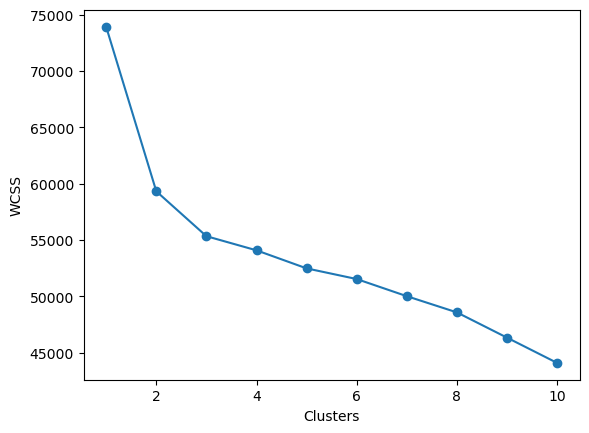

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [18]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(scaled_data)

df["Cluster"] = clusters

In [19]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    scaled_data,
    clusters
)

print(score)

0.12420731344070281


In [20]:
df.groupby("Cluster").mean()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Age,Total_Spending,Total_Purchases,Family_Size
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1972.188623,34444.595574,0.816367,0.429142,49.318363,38.100798,4.818363,22.224551,6.899202,4.962076,...,0.096806,0.384232,0.239521,0.253493,0.023952,0.000000,53.811377,92.534930,5.720559,2.245509
1,1967.435393,71480.681893,0.070225,0.359551,51.210674,463.643258,78.148876,348.494382,110.713483,81.033708,...,0.092697,0.443820,0.151685,0.258427,0.047753,0.000000,58.564607,1175.311798,19.766854,1.429775
2,1963.582624,57025.466370,0.243612,0.954003,48.066440,432.413969,17.269165,120.548552,24.838160,17.206133,...,0.126065,0.398637,0.155026,0.272572,0.042589,0.003407,62.417376,666.701874,16.212947,2.197615
3,1969.362712,79997.582217,0.030508,0.054237,47.938983,758.491525,54.681356,531.772881,78.474576,56.613559,...,0.094915,0.294915,0.322034,0.250847,0.037288,0.000000,56.637288,1540.688136,19.650847,1.084746


In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

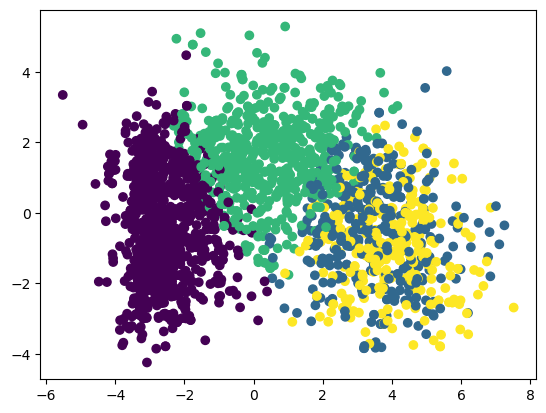

In [23]:
plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=clusters
)

plt.show()